# Chapter 2 - Data and Sampling Distributions

Chapter ini membahas konsep data dan sampling distributions.

Dalam data science, sampling tetap penting meskipun kita hidup di era
big data. Sampling dapat digunakan untuk bekerja secara efisien dengan
data, mengurangi bias, dan memahami seberapa besar ketidakpastian
yang terdapat pada suatu estimasi.

Chapter ini membahas:
- Random sampling dan sample bias
- Selection bias
- Regression to the mean
- Sampling distribution
- Central Limit Theorem
- Standard error
- Bootstrap
- Confidence intervals
- Normal distribution
- Student's t-distribution
- Binomial distribution
- Chi-square distribution
- F-distribution
- Poisson dan related distributions

## Random Sampling and Sample Bias

Random sampling adalah proses memilih sampel secara acak dari suatu
populasi.

Tujuan utama random sampling adalah mendapatkan sampel yang dapat
merepresentasikan populasi dengan baik.

Sampling sangat penting karena kita sering kali tidak dapat
menggunakan seluruh populasi. Dengan mengambil sampel secara tepat,
kita dapat melakukan analisis dengan jumlah data yang lebih kecil.

Namun, proses sampling dapat menghasilkan bias apabila sampel yang
dipilih tidak mewakili populasi.

### Bias

Bias adalah kesalahan sistematis yang berasal dari proses pengukuran
atau proses sampling.

Bias berbeda dengan random error.

Random error dapat terjadi karena faktor kebetulan dan tidak selalu
bergerak ke arah tertentu. Sebaliknya, bias menyebabkan hasil
cenderung menyimpang ke arah tertentu.

Dengan demikian, data yang memiliki jumlah besar belum tentu bebas
dari bias. Jika proses pengumpulan datanya bias, menambah jumlah data
tidak otomatis menghilangkan bias.

### Self-Selection Sampling Bias

Self-selection bias terjadi ketika orang memilih sendiri apakah mereka
akan masuk ke dalam sampel.

Contohnya adalah review restoran di media sosial.

Orang yang memilih untuk memberikan review mungkin memiliki
karakteristik atau pengalaman yang berbeda dengan orang yang tidak
memberikan review.

Akibatnya, kumpulan review tersebut belum tentu merepresentasikan
seluruh pelanggan restoran.

### Random Selection

Random selection berarti memilih anggota populasi secara acak
berdasarkan prosedur sampling tertentu.

Sebelum melakukan random sampling, kita harus menentukan terlebih
dahulu populasi yang ingin diteliti.

Contohnya, jika ingin melakukan survei pelanggan, kita harus
menentukan siapa yang termasuk pelanggan.

Setelah populasi ditentukan, kita dapat menentukan prosedur sampling,
misalnya memilih 100 pelanggan secara acak.

Pada stratified sampling, populasi dibagi menjadi beberapa kelompok
(strata), kemudian sampel acak diambil dari setiap kelompok.

### Size Versus Quality: When Does Size Matter?

Jumlah data yang besar tidak selalu menjamin hasil analisis yang
lebih baik.

Kualitas dan cara pemilihan data juga sangat penting.

Sampel yang besar tetapi memiliki bias dapat menghasilkan estimasi
yang buruk. Sebaliknya, sampel yang lebih kecil tetapi dipilih dengan
prosedur yang baik dapat memberikan informasi yang lebih berguna.

Oleh karena itu, dalam sampling perlu diperhatikan dua hal:
1. Ukuran sampel
2. Kualitas dan representativitas sampel

### Sample Mean Versus Population Mean

Population adalah keseluruhan objek atau observasi yang menjadi
perhatian dalam suatu penelitian.

Sample adalah sebagian data yang diambil dari population.

Population mean adalah rata-rata dari seluruh populasi.

Sample mean adalah rata-rata dari data yang terdapat dalam sample.

Sample mean digunakan untuk memperkirakan population mean.

Karena sample hanya merupakan sebagian dari populasi, sample mean
dapat berbeda dari population mean.

### Contoh Sampling *Distribution*

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
loans_income = pd.read_csv(
    'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loans_income.csv'
).squeeze()

In [6]:
print(type(loans_income))
print(loans_income.shape)
print(loans_income.head())

<class 'pandas.core.series.Series'>
(50000,)
0     67000
1     52000
2    100000
3     78762
4     37041
Name: x, dtype: int64


In [7]:
loans_income.head()

,x
0,67000
1,52000
2,100000
3,78762
4,37041


### Sampling Distribution of a Statistic

Sampling distribution adalah distribusi dari suatu sample statistic
yang diperoleh dari banyak sampel yang berasal dari populasi yang sama.

Contohnya, kita dapat mengambil banyak sampel dari data income dan
menghitung mean masing-masing sampel.

Distribusi dari seluruh sample mean tersebut disebut sampling
distribution of the mean.

Sampling distribution berbeda dengan data distribution.

Data distribution menunjukkan distribusi nilai individual dalam data,
sedangkan sampling distribution menunjukkan distribusi suatu
statistik yang dihitung dari banyak sampel.

## Reproduce Code Book

In [8]:
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

results = pd.concat([
    sample_data,
    sample_mean_05,
    sample_mean_20
])

DATA

In [9]:
loans_income.sample(1000)

,x
17431,70000
3643,130000
25226,49000
39238,105000
29831,53748
...,...
27642,37000
33368,50000
19300,62774
4910,51000


MEAN OF 5

In [10]:
[loans_income.sample(5).mean() for _ in range(1000)]

[np.float64(83780.0),
 np.float64(62200.0),
 np.float64(49840.0),
 np.float64(88600.0),
 np.float64(57939.0),
 np.float64(103647.6),
 np.float64(84872.6),
 np.float64(110802.4),
 np.float64(73800.0),
 np.float64(62591.2),
 np.float64(47716.0),
 np.float64(79321.8),
 np.float64(64438.4),
 np.float64(55400.0),
 np.float64(64368.4),
 np.float64(69600.0),
 np.float64(75350.0),
 np.float64(82400.0),
 np.float64(72140.0),
 np.float64(76314.4),
 np.float64(64000.0),
 np.float64(55012.0),
 np.float64(85600.0),
 np.float64(66912.2),
 np.float64(56599.6),
 np.float64(63200.0),
 np.float64(94800.0),
 np.float64(55588.0),
 np.float64(99200.0),
 np.float64(56800.0),
 np.float64(55837.6),
 np.float64(63020.0),
 np.float64(77800.0),
 np.float64(61200.0),
 np.float64(65800.0),
 np.float64(78100.0),
 np.float64(75700.0),
 np.float64(84800.0),
 np.float64(73760.0),
 np.float64(81600.0),
 np.float64(74000.0),
 np.float64(70700.0),
 np.float64(82738.2),
 np.float64(77200.8),
 np.float64(63800.0),
 np.floa

MEAN OF 20

In [11]:
[loans_income.sample(20).mean() for _ in range(1000)]

[np.float64(68110.0),
 np.float64(62244.6),
 np.float64(72518.65),
 np.float64(68305.0),
 np.float64(70227.95),
 np.float64(63865.0),
 np.float64(77527.5),
 np.float64(59466.55),
 np.float64(67726.15),
 np.float64(72798.95),
 np.float64(66776.1),
 np.float64(83379.8),
 np.float64(72526.0),
 np.float64(76290.0),
 np.float64(69969.9),
 np.float64(69295.4),
 np.float64(79542.7),
 np.float64(65605.8),
 np.float64(62669.1),
 np.float64(59118.8),
 np.float64(55728.0),
 np.float64(66870.15),
 np.float64(69307.7),
 np.float64(72376.3),
 np.float64(69270.25),
 np.float64(68229.9),
 np.float64(67102.0),
 np.float64(64715.0),
 np.float64(64283.6),
 np.float64(77935.0),
 np.float64(69010.0),
 np.float64(74938.75),
 np.float64(69347.75),
 np.float64(59813.15),
 np.float64(68415.85),
 np.float64(78527.85),
 np.float64(76348.25),
 np.float64(68661.8),
 np.float64(89324.65),
 np.float64(59085.2),
 np.float64(65934.2),
 np.float64(65132.2),
 np.float64(82590.0),
 np.float64(65617.1),
 np.float64(70907.

## Visualisasi Sampling Distribution

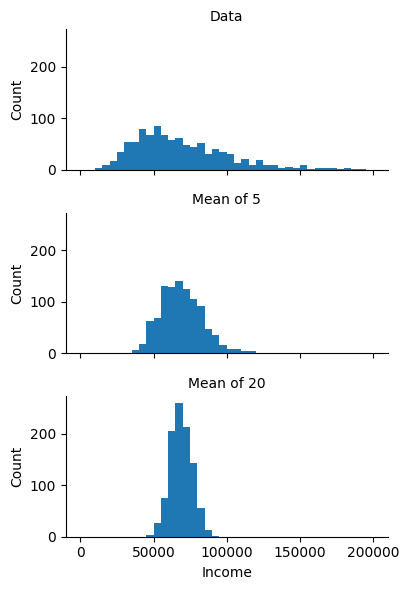

In [12]:
g = sns.FacetGrid(
    results,
    col='type',
    col_wrap=1,
    height=2,
    aspect=2
)

g.map(
    plt.hist,
    'income',
    range=[0, 200000],
    bins=40
)

g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.show()

### Interpretasi

Histogram menunjukkan perbedaan antara data distribution dan sampling
distribution.

Distribusi data individual memiliki penyebaran yang lebih luas dan
cenderung skewed.

Ketika mean dihitung dari sampel berukuran 5, distribusinya menjadi
lebih terkonsentrasi.

Ketika ukuran sampel meningkat menjadi 20, distribusi sample mean
menjadi semakin sempit dan lebih menyerupai distribusi berbentuk
bell curve.

Hal ini menunjukkan bahwa semakin besar ukuran sampel, sample mean
cenderung memiliki variabilitas yang lebih kecil.

## Central Limit Theorem

Central Limit Theorem (CLT) menjelaskan kecenderungan sampling
distribution dari sample mean menjadi berbentuk normal ketika ukuran
sampel cukup besar.

Hal ini dapat terjadi meskipun distribusi data asal tidak berbentuk
normal, selama ukuran sampel cukup besar dan penyimpangan data dari
normalitas tidak terlalu ekstrem.

Central Limit Theorem menjadi dasar bagi penggunaan beberapa formula
statistik untuk melakukan inference.

## Standard Error

Standard error (SE) digunakan untuk mengukur variabilitas dari suatu
sample statistic.

Untuk sample mean, standard error dapat diperkirakan dengan:

SE = s / √n

dengan:

s = standard deviation dari sample
n = ukuran sample

Semakin besar ukuran sample, semakin kecil standard error.

Hal ini berarti sample mean cenderung menjadi lebih stabil ketika
ukuran sample bertambah.

## The Bootstrap

The bootstrap is a general method for estimating the sampling distribution of a statistic by repeatedly sampling with replacement from the observed data.

The basic idea is:
1. Start with the observed sample.
2. Draw a new sample of the same size with replacement.
3. Calculate the statistic of interest.
4. Repeat the process many times.
5. Use the resulting distribution to estimate the variability of the statistic.

The bootstrap is useful because it can estimate the uncertainty of a statistic without requiring strong assumptions about the underlying population distribution.

### Reproduce code - Bootstrap

In [13]:
results = []

for n in range(1000):
    sample = loans_income.sample(
        100,
        replace=True
    )
    results.append(sample.mean())

bootstrap = pd.Series(results)

print(bootstrap.head())

0    69454.88
1    69175.11
2    66336.97
3    63627.99
4    66557.79
dtype: float64


### Visualisasi Bootstrap

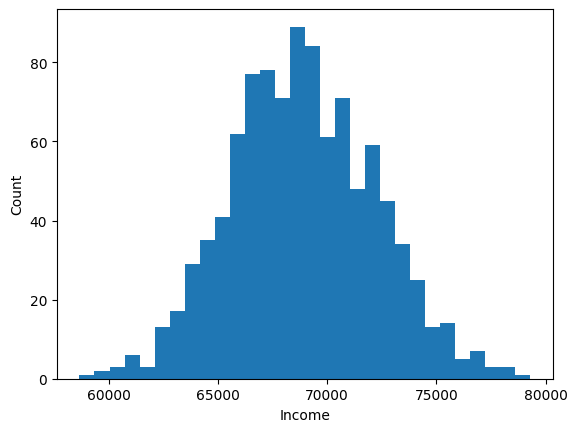

In [14]:
ax = bootstrap.plot.hist(bins=30)

ax.set_xlabel('Income')
ax.set_ylabel('Count')

plt.show()

Histogram ini menunjukkan bagaimana nilai mean berubah ketika kita melakukan bootstrap berkali-kali.

Kalau distribusinya relatif sempit, berarti estimasi mean memiliki variasi yang relatif kecil.

In [16]:
from sklearn.utils import resample

results = []

for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.mean())

results = pd.Series(results)

print("Jumlah hasil bootstrap:", len(results))
print("Rata-rata hasil bootstrap:", results.mean())

Jumlah hasil bootstrap: 1000
Rata-rata hasil bootstrap: 68761.81483513999


In [17]:
results.head()

,0
0,68625.02306
1,68951.75214
2,68554.36754
3,68760.07746
4,68576.84354


## Confidence Intervals

Confidence interval (interval kepercayaan) digunakan untuk memberikan rentang nilai yang masuk akal untuk suatu parameter populasi berdasarkan data sampel.

Daripada hanya memberikan satu nilai estimasi, confidence interval memberikan rentang yang menunjukkan ketidakpastian dari estimasi tersebut.

Confidence interval memiliki tingkat kepercayaan, misalnya 90% atau 95%.

Dengan menggunakan bootstrap, confidence interval dapat diperoleh dari distribusi hasil bootstrap.

### Prosedur Bootstrap Confidence Interval

1. Mengambil sampel secara acak dengan replacement dari data.
2. Menghitung statistik yang ingin dianalisis.
3. Mengulangi proses tersebut berkali-kali.
4. Mengurutkan hasil statistik dari seluruh bootstrap sample.
5. Menentukan batas bawah dan batas atas berdasarkan tingkat confidence interval.
6. Rentang antara kedua batas tersebut menjadi bootstrap confidence interval.

In [18]:
# Menentukan batas bawah dan batas atas confidence interval 90%

batas_bawah = results.quantile(0.05)
batas_atas = results.quantile(0.95)

print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

Batas bawah: 68521.532944
Batas atas: 69015.464171


## Visualisasi Confidence Interval

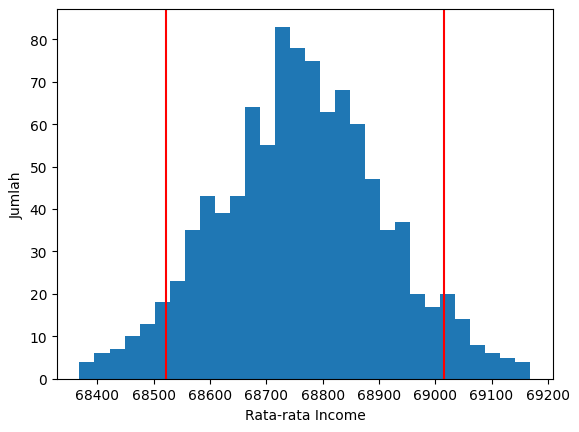

In [19]:
ax = results.plot.hist(bins=30)

ax.axvline(batas_bawah, color='red')
ax.axvline(batas_atas, color='red')

ax.set_xlabel('Rata-rata Income')
ax.set_ylabel('Jumlah')

plt.show()

## Normal Distribution

Normal distribution adalah distribusi probabilitas yang berbentuk simetris seperti lonceng.

Distribusi normal memiliki dua parameter utama:
- Mean (μ), yang menentukan lokasi pusat distribusi.
- Standard deviation (σ), yang menentukan tingkat penyebaran data.

Pada distribusi normal, nilai yang berada dekat dengan mean memiliki probabilitas yang lebih tinggi dibandingkan nilai yang jauh dari mean.

### Standard Normal Distribution

Standard normal distribution merupakan distribusi normal dengan:
- mean = 0
- standard deviation = 1

Nilai pada standard normal distribution dapat dinyatakan menggunakan z-score.

Z-score menunjukkan seberapa jauh suatu nilai dari mean dalam satuan standard deviation.

## Visualisasi Normal Distribution

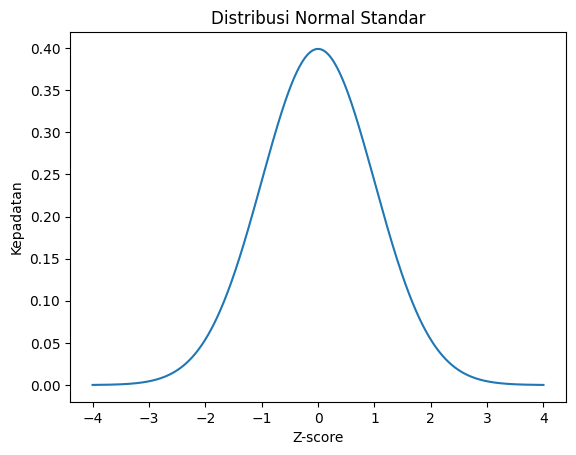

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)

y = norm.pdf(x, loc=0, scale=1)

plt.plot(x, y)

plt.xlabel('Z-score')
plt.ylabel('Kepadatan')
plt.title('Distribusi Normal Standar')

plt.show()

### Mean dan Standard Deviation

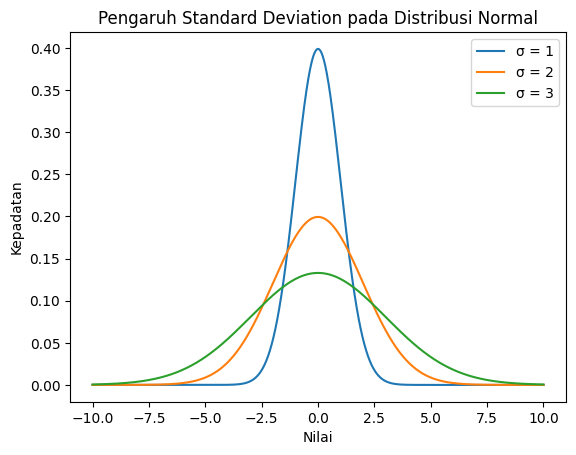

In [21]:
x = np.linspace(-10, 10, 1000)

plt.plot(x, norm.pdf(x, 0, 1), label='σ = 1')
plt.plot(x, norm.pdf(x, 0, 2), label='σ = 2')
plt.plot(x, norm.pdf(x, 0, 3), label='σ = 3')

plt.xlabel('Nilai')
plt.ylabel('Kepadatan')
plt.title('Pengaruh Standard Deviation pada Distribusi Normal')
plt.legend()

plt.show()

### Normal Distribution dan Sampling

Distribusi normal sering digunakan dalam statistik untuk menggambarkan distribusi data dan distribusi sampling.

Central Limit Theorem menjelaskan bahwa distribusi sampling dari mean akan mendekati distribusi normal ketika ukuran sampel cukup besar, meskipun distribusi populasi awal tidak normal.

Karena itu, distribusi normal memiliki peranan penting dalam inferensi statistik.

### Key Ideas

- Distribusi normal berbentuk simetris seperti lonceng.
- Distribusi normal ditentukan oleh mean dan standard deviation.
- Standard normal distribution memiliki mean 0 dan standard deviation 1.
- Z-score menunjukkan posisi suatu nilai relatif terhadap mean dalam satuan standard deviation.
- Distribusi normal memiliki peranan penting dalam statistik dan inferensi.

## Student's t-Distribution

Student's t-distribution adalah distribusi yang bentuknya menyerupai distribusi normal, tetapi memiliki ekor yang lebih tebal dan lebih panjang.

t-distribution digunakan untuk menggambarkan distribusi statistik sampel, terutama ketika ukuran sampel relatif kecil.

Terdapat keluarga t-distribution yang berbeda berdasarkan ukuran sampel dan degrees of freedom.

Semakin besar ukuran sampel, bentuk t-distribution akan semakin mendekati distribusi normal.

### Degrees of Freedom

Degrees of freedom (df) adalah parameter yang digunakan untuk menyesuaikan bentuk t-distribution berdasarkan ukuran sampel.

Untuk distribusi t yang digunakan pada sample mean, degrees of freedom umumnya dihitung sebagai:

df = n - 1

dengan:
- n = ukuran sampel
- df = degrees of freedom

### Hubungan Ukuran Sampel dan t-Distribution

t-distribution memiliki keluarga distribusi yang berbeda untuk degrees of freedom yang berbeda.

Ketika ukuran sampel semakin besar, degrees of freedom juga semakin besar.

Semakin besar degrees of freedom, bentuk t-distribution semakin mendekati distribusi normal.

### Visualisasi t-Distribution

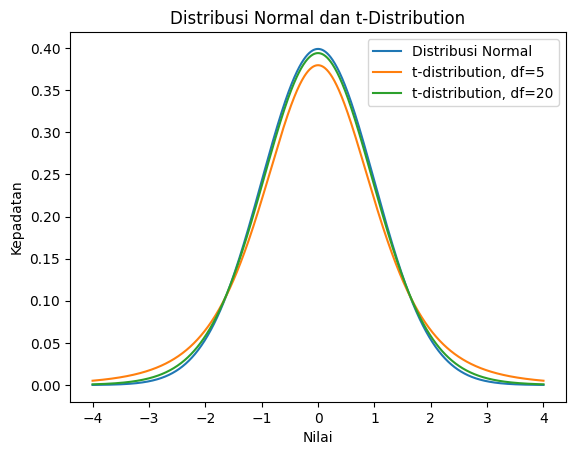

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

x = np.linspace(-4, 4, 1000)

plt.plot(x, norm.pdf(x), label='Distribusi Normal')
plt.plot(x, t.pdf(x, df=5), label='t-distribution, df=5')
plt.plot(x, t.pdf(x, df=20), label='t-distribution, df=20')

plt.xlabel('Nilai')
plt.ylabel('Kepadatan')
plt.title('Distribusi Normal dan t-Distribution')

plt.legend()
plt.show()

### t-Distribution dan Confidence Interval

t-distribution dapat digunakan untuk membentuk confidence interval dari sample mean.

Bentuk umumnya adalah:

sample mean ± t × (sample standard deviation / √n)

dengan:
- sample mean = rata-rata sampel
- t = nilai t-statistic berdasarkan degrees of freedom dan confidence level
- sample standard deviation = standar deviasi sampel
- n = ukuran sampel
- degrees of freedom = n - 1

### Mengambil Nilai t

In [23]:
from scipy.stats import t

df = 9

nilai_t = t.ppf(0.95, df)

print("Degrees of freedom:", df)
print("Nilai t:", nilai_t)

Degrees of freedom: 9
Nilai t: 1.8331129326536335


### Confidence Interval dengan t-Distribution

In [24]:
import numpy as np
from scipy.stats import t

data = np.array([10, 12, 11, 13, 15, 14, 12, 11, 13, 14])

n = len(data)
mean = data.mean()
std = data.std(ddof=1)

df = n - 1
t_value = t.ppf(0.95, df)

margin_error = t_value * std / np.sqrt(n)

lower = mean - margin_error
upper = mean + margin_error

print("Mean:", mean)
print("Degrees of freedom:", df)
print("Confidence Interval 90%:")
print("Batas bawah:", lower)
print("Batas atas:", upper)

Mean: 12.5
Degrees of freedom: 9
Confidence Interval 90%:
Batas bawah: 11.583443533673183
Batas atas: 13.416556466326817


### Key Ideas

- t-distribution merupakan keluarga distribusi yang menyerupai distribusi normal tetapi memiliki ekor yang lebih tebal.
- Bentuk t-distribution dipengaruhi oleh degrees of freedom.
- Semakin besar ukuran sampel, t-distribution semakin mendekati distribusi normal.
- t-distribution banyak digunakan sebagai distribusi acuan untuk sample mean, perbedaan antara dua sample mean, parameter regresi, dan statistik lainnya.
- Bootstrap dapat digunakan sebagai pendekatan alternatif untuk mempelajari sampling error dalam banyak situasi.

## Binomial Distribution

Binomial distribution digunakan untuk memodelkan jumlah keberhasilan (successes) dalam sejumlah percobaan (trials).

Setiap percobaan memiliki dua kemungkinan hasil:
- Success (berhasil)
- Failure (gagal)

Binomial distribution digunakan ketika:
- jumlah percobaan ditentukan,
- setiap percobaan memiliki dua kemungkinan hasil,
- peluang keberhasilan relatif tetap,
- dan setiap percobaan dianggap independen.

Binomial distribution banyak digunakan untuk memodelkan jumlah keberhasilan dalam sejumlah percobaan.

### Parameter Binomial Distribution

Binomial distribution memiliki dua parameter utama:

- n = jumlah percobaan (trials)
- p = probabilitas keberhasilan pada setiap percobaan

Jumlah keberhasilan biasanya dilambangkan dengan X.

Contoh:

Jika dilakukan 10 percobaan dengan probabilitas keberhasilan 0.5, maka:

n = 10
p = 0.5

### Visualisasi Binomial Distribution

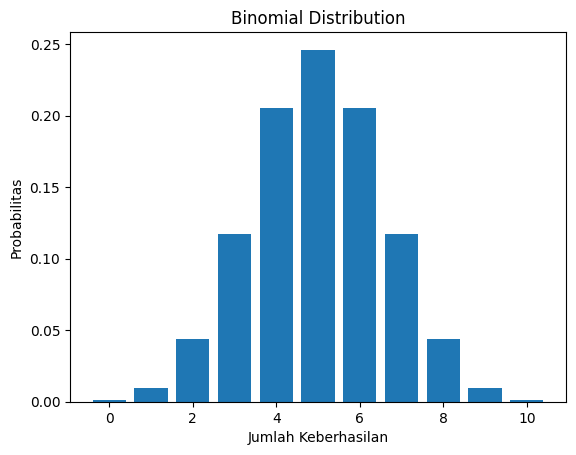

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10
p = 0.5

x = np.arange(0, n + 1)
probabilitas = binom.pmf(x, n, p)

plt.bar(x, probabilitas)

plt.xlabel('Jumlah Keberhasilan')
plt.ylabel('Probabilitas')
plt.title('Binomial Distribution')

plt.show()

### Menghitung Probabilitas

In [2]:
probabilitas_5 = binom.pmf(5, n, p)

print("Probabilitas mendapatkan tepat 5 keberhasilan:", probabilitas_5)

Probabilitas mendapatkan tepat 5 keberhasilan: 0.24609375000000003


In [3]:
probabilitas_5_atau_lebih = binom.sf(4, n, p)

print("Probabilitas mendapatkan 5 keberhasilan atau lebih:",
      probabilitas_5_atau_lebih)

Probabilitas mendapatkan 5 keberhasilan atau lebih: 0.623046875


### Penerapan Binomial Distribution

Binomial distribution dapat digunakan ketika kita ingin mengetahui jumlah keberhasilan dari sejumlah percobaan dengan dua kemungkinan hasil.

Contohnya dapat digunakan untuk:
- jumlah pelanggan yang melakukan pembelian dari sejumlah pelanggan,
- jumlah email yang dibuka dari sejumlah email,
- jumlah produk yang berhasil dari sejumlah produk yang diuji,
- atau jumlah keberhasilan dari sejumlah percobaan lainnya.

### Binomial Distribution dan Normal Distribution

Binomial distribution digunakan untuk data berupa jumlah keberhasilan dari sejumlah percobaan.

Normal distribution digunakan untuk data kontinu dan berbentuk distribusi yang simetris seperti lonceng.

Binomial distribution memiliki nilai diskrit, sedangkan normal distribution merupakan distribusi kontinu.

### Key Ideas

- Binomial distribution digunakan untuk memodelkan jumlah keberhasilan dalam sejumlah percobaan.
- Setiap percobaan memiliki dua kemungkinan hasil.
- Binomial distribution ditentukan oleh jumlah percobaan (n) dan probabilitas keberhasilan (p).
- Nilai yang dimodelkan merupakan jumlah keberhasilan, sehingga bersifat diskrit.
- Binomial distribution dapat digunakan untuk menghitung probabilitas jumlah keberhasilan tertentu.

## Chi-Square Distribution

Chi-square distribution adalah distribusi probabilitas yang banyak digunakan dalam statistik untuk menganalisis variabilitas dan data kategorikal.

Chi-square distribution memiliki parameter yang disebut degrees of freedom (df).

Bentuk distribusi chi-square bergantung pada jumlah degrees of freedom.

### Degrees of Freedom

Chi-square distribution memiliki degrees of freedom (df) sebagai parameter.

Perubahan degrees of freedom akan mengubah bentuk distribusi.

Ketika degrees of freedom semakin besar, distribusi chi-square menjadi semakin menyebar dan bentuknya semakin mendekati distribusi yang lebih simetris.

### Visualisasi Chi-Square Distribution

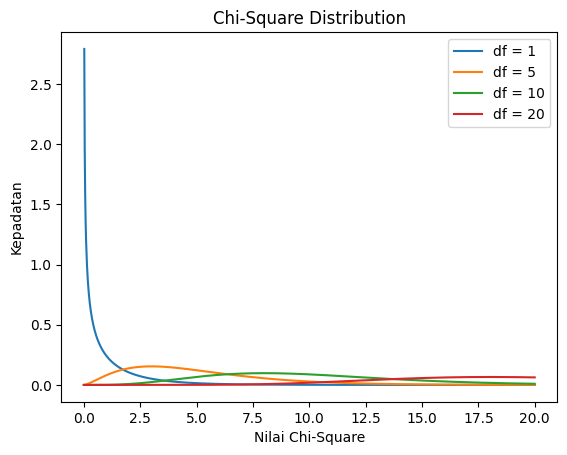

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

x = np.linspace(0, 20, 1000)

plt.plot(x, chi2.pdf(x, df=1), label='df = 1')
plt.plot(x, chi2.pdf(x, df=5), label='df = 5')
plt.plot(x, chi2.pdf(x, df=10), label='df = 10')
plt.plot(x, chi2.pdf(x, df=20), label='df = 20')

plt.xlabel('Nilai Chi-Square')
plt.ylabel('Kepadatan')
plt.title('Chi-Square Distribution')

plt.legend()
plt.show()

### Chi-Square dan Varians

Chi-square distribution dapat digunakan dalam inferensi mengenai varians populasi.

Statistik chi-square dapat dibentuk dari varians sampel dan varians populasi:

χ² = (n - 1)s² / σ²

dengan:
- n = ukuran sampel
- s² = varians sampel
- σ² = varians populasi
- χ² = statistik chi-square
- df = n - 1

### Menghitung Nilai Chi-Square

In [5]:
n = 10
sample_variance = 4
population_variance = 2

chi_square = (n - 1) * sample_variance / population_variance

print("Nilai Chi-Square:", chi_square)
print("Degrees of freedom:", n - 1)

Nilai Chi-Square: 18.0
Degrees of freedom: 9


### Visualisasi Distribusi Chi-Square

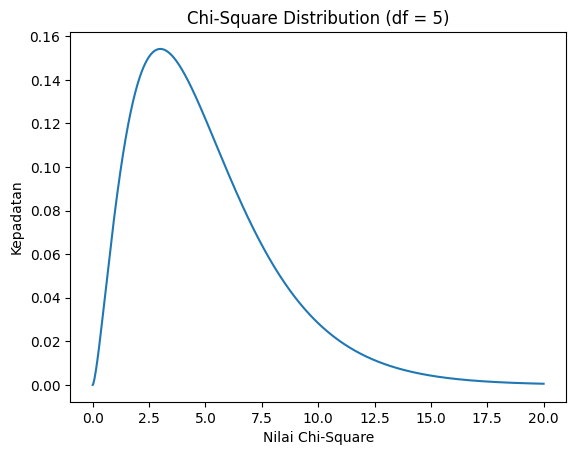

In [6]:
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

df = 5

x = np.linspace(0, 20, 1000)
y = chi2.pdf(x, df)

plt.plot(x, y)

plt.xlabel('Nilai Chi-Square')
plt.ylabel('Kepadatan')
plt.title(f'Chi-Square Distribution (df = {df})')

plt.show()

### Key Ideas

- Chi-square distribution merupakan distribusi probabilitas yang digunakan dalam berbagai analisis statistik.
- Chi-square distribution hanya memiliki nilai mulai dari 0.
- Bentuk distribusi chi-square dipengaruhi oleh degrees of freedom.
- Chi-square dapat digunakan dalam analisis yang berkaitan dengan varians.
- Chi-square juga digunakan pada analisis data kategorikal, terutama ketika membandingkan frekuensi yang diamati dengan frekuensi yang diharapkan.

## F-Distribution

F-distribution digunakan pada eksperimen dan linear model yang melibatkan data yang dapat diukur.

Dalam suatu eksperimen dengan beberapa kelompok, kita dapat membandingkan:
- variasi antar-group atau group means
- variasi di dalam masing-masing group (residual variability)

F-statistic merupakan rasio antara variasi yang berkaitan dengan faktor yang diamati dengan variasi residual.

F-distribution merupakan distribusi dari nilai-nilai F-statistic yang dihasilkan ketika data secara acak dipermutasi dengan asumsi bahwa semua group memiliki mean yang sama.

F-distribution digunakan dalam:
- Analysis of Variance (ANOVA)
- Linear regression

Key ideas:
- F-distribution digunakan pada eksperimen dan linear models dengan measured data.
- F-statistic membandingkan variasi yang disebabkan oleh faktor yang menjadi perhatian dengan variasi keseluruhan/residual.

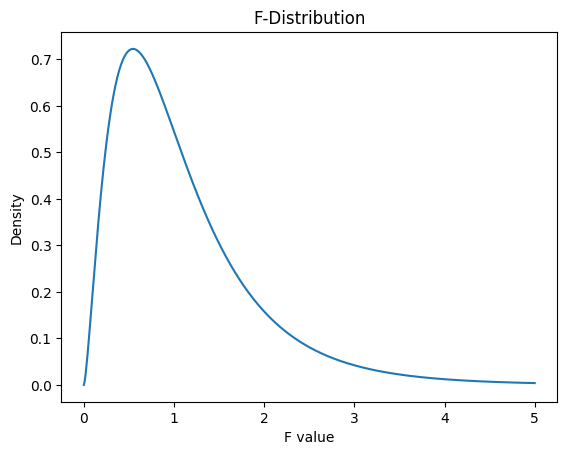

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(0, 5, 500)

df1 = 5
df2 = 20

y = stats.f.pdf(x, df1, df2)

plt.plot(x, y)

plt.xlabel('F value')
plt.ylabel('Density')
plt.title('F-Distribution')

plt.show()

### Melihat pengaruh degrees of freedom

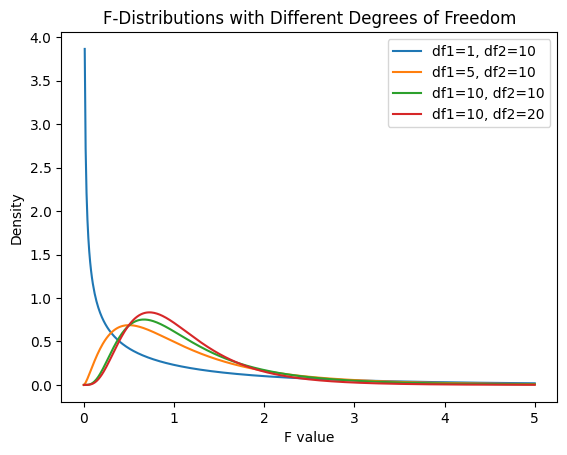

In [8]:
x = np.linspace(0, 5, 500)

df_pairs = [
    (1, 10),
    (5, 10),
    (10, 10),
    (10, 20)
]

for df1, df2 in df_pairs:
    y = stats.f.pdf(x, df1, df2)
    plt.plot(x, y, label=f'df1={df1}, df2={df2}')

plt.xlabel('F value')
plt.ylabel('Density')
plt.title('F-Distributions with Different Degrees of Freedom')
plt.legend()

plt.show()

### Menghitung nilai F tertentu

In [9]:
df1 = 5
df2 = 20

f_critical = stats.f.ppf(0.95, df1, df2)

print("F critical:", f_critical)

F critical: 2.7108898372096917


### Hubungan F-Distribution dengan ANOVA

F-distribution digunakan dalam Analysis of Variance (ANOVA).

ANOVA digunakan ketika kita ingin membandingkan beberapa kelompok yang memiliki data numerik.

F-statistic membandingkan:

F = variasi antar-group / variasi residual

Semakin besar rasio tersebut, semakin besar pula F-statistic.

Dalam ANOVA, F-statistic kemudian dibandingkan dengan F-distribution untuk menentukan seberapa besar nilai tersebut dibandingkan dengan variasi yang dapat terjadi secara acak.

### Contoh ANOVA

In [10]:
from scipy import stats

group_a = [10, 11, 12, 10, 11]
group_b = [15, 14, 16, 15, 14]
group_c = [20, 19, 21, 20, 22]

f_stat, p_value = stats.f_oneway(
    group_a,
    group_b,
    group_c
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 129.18518518518468
p-value: 7.64421512432372e-09


### Key Ideas — F-Distribution

1. F-distribution digunakan dengan eksperimen dan linear models yang melibatkan measured data.

2. F-statistic membandingkan variasi yang disebabkan oleh faktor yang menjadi perhatian dengan variasi residual/overall variation.

3. F-statistic digunakan dalam ANOVA untuk membandingkan variasi antar-group dengan variasi di dalam group.

4. F-statistic juga digunakan dalam linear regression untuk membandingkan variasi yang dijelaskan oleh regression model dengan variasi keseluruhan dalam data.

## Poisson and Related Distributions

Banyak proses menghasilkan kejadian (events) secara acak dengan suatu tingkat kejadian
(rate) tertentu.

Contohnya:
- pengunjung yang datang ke website,
- mobil yang datang ke gerbang tol,
- jumlah cacat pada suatu area kain,
- jumlah kesalahan (typos) dalam sejumlah baris kode.

Distribusi yang dibahas dalam bagian ini adalah:

1. Poisson distribution
2. Exponential distribution
3. Weibull distribution

Key Terms:

- Lambda (λ): tingkat/rate terjadinya event per unit waktu atau ruang.
- Poisson distribution: distribusi jumlah event dalam unit waktu atau ruang tertentu.
- Exponential distribution: distribusi waktu atau jarak antara satu event dengan event berikutnya.
- Weibull distribution: bentuk generalisasi dari exponential distribution ketika event rate
  diperbolehkan berubah seiring waktu.

### Simulasi Poisson Distribution

In [11]:
from scipy import stats

stats.poisson.rvs(2, size=100)

array([5, 2, 1, 2, 3, 1, 4, 4, 2, 1, 2, 3, 2, 3, 1, 1, 3, 4, 0, 4, 1, 4,
       5, 3, 5, 3, 2, 0, 0, 0, 0, 1, 3, 1, 0, 3, 1, 1, 0, 3, 1, 4, 4, 1,
       0, 3, 2, 1, 1, 1, 2, 0, 1, 2, 1, 0, 3, 2, 0, 2, 6, 2, 1, 1, 2, 3,
       1, 0, 2, 1, 3, 3, 2, 0, 1, 3, 2, 1, 0, 0, 3, 0, 3, 2, 4, 1, 2, 8,
       1, 3, 2, 5, 3, 2, 2, 1, 3, 2, 4, 1])

In [13]:
from scipy import stats

# Simulasi jumlah kejadian dengan distribusi Poisson
# lambda = 2, sebanyak 100 data
calls = stats.poisson.rvs(2, size=100)

print(calls[:20])

[3 0 2 0 0 2 0 4 4 1 0 1 3 2 0 2 1 4 3 1]


### Visualisasi Poisson Distribution

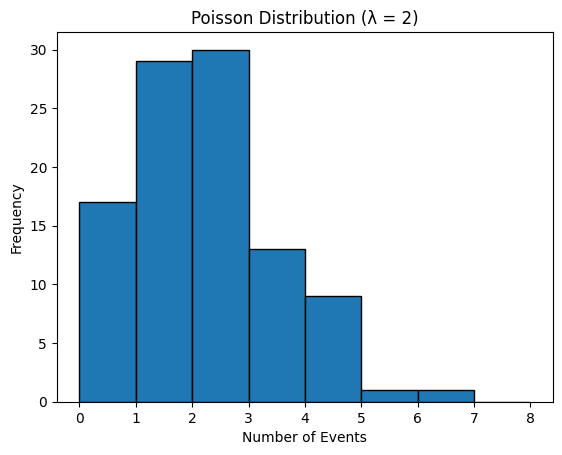

In [14]:
import matplotlib.pyplot as plt

plt.hist(calls, bins=range(0, 9), edgecolor='black')

plt.xlabel('Number of Events')
plt.ylabel('Frequency')
plt.title('Poisson Distribution (λ = 2)')

plt.show()

### Lambda (λ)

Lambda merupakan parameter utama dalam Poisson distribution.

λ menunjukkan rata-rata jumlah event yang terjadi dalam suatu unit waktu atau ruang.

Dalam Poisson distribution:

Mean = λ

Variance = λ

Contoh:

Jika rata-rata terdapat 2 customer service calls per menit:

λ = 2

Maka:
- rata-rata jumlah panggilan per menit = 2
- variance = 2

### Simulasi Exponential Distribution

In [15]:
from scipy import stats

intervals = stats.expon.rvs(0.2, size=100)

print(intervals)

[2.0132106  1.20446503 0.60672581 1.28332722 0.37089613 0.9172382
 2.21425121 3.41740268 2.62498626 0.76580509 2.56137919 0.37713379
 0.42857652 0.28207907 0.76837821 2.38922223 0.71175753 1.18403173
 1.20744702 0.75224063 0.29860399 0.64026949 1.1648231  2.22546285
 2.04225334 1.21490117 3.86303251 0.37250775 1.42468646 0.76058789
 0.41333194 0.43536934 0.36799876 1.30827278 0.26223862 0.63109478
 2.79470394 4.44750948 0.38463045 0.54067243 1.25789625 0.25294808
 0.27777293 0.28656751 2.06500673 1.46555105 0.54190525 0.95538895
 3.20864982 0.68321398 4.8882622  1.03470786 1.28653255 1.38080416
 3.30274066 0.42544143 0.34640295 1.26102328 0.83627258 1.27601403
 2.46573537 0.56415726 0.48230878 0.42196836 0.89332086 0.66248225
 0.92921239 1.52758094 1.83731514 0.54189868 1.57888282 1.62918707
 0.27313649 1.62486167 0.65373855 1.62685322 0.75851963 0.26878035
 1.44972923 1.9601005  2.29025137 1.7426162  0.34177509 2.83189242
 1.06719732 1.31130495 2.72946465 0.34964066 1.17186112 0.21359

### Visualisasi Exponential Distribution

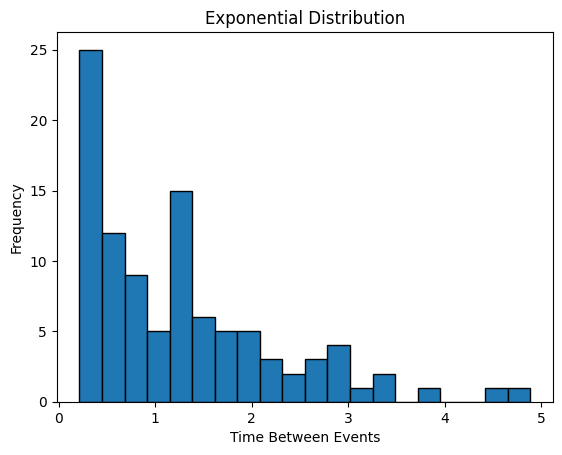

In [16]:
plt.hist(intervals, bins=20, edgecolor='black')

plt.xlabel('Time Between Events')
plt.ylabel('Frequency')
plt.title('Exponential Distribution')

plt.show()

### Estimating the Failure Rate

Pada beberapa aplikasi, event rate (λ) dapat diketahui atau diperkirakan
berdasarkan data sebelumnya.

Namun, untuk rare events, estimasi λ dapat menjadi sulit karena jumlah data
yang tersedia sangat sedikit.

Contohnya adalah aircraft engine failure.

Jika tidak ada event yang diamati selama periode tertentu, kita tetap dapat
menggunakan probabilitas atau simulasi untuk mengevaluasi berbagai kemungkinan
event rate.

Jika tersedia sebagian data tetapi belum cukup untuk memberikan estimasi rate
yang presisi, goodness-of-fit test dapat digunakan untuk mengevaluasi berbagai
kemungkinan rate terhadap data yang diamati.

### Weibull Distribution

Weibull distribution merupakan pengembangan dari exponential distribution
yang memungkinkan event rate berubah seiring waktu.

Perubahan event rate ditentukan oleh shape parameter β (beta).

Jika:

β > 1
→ probabilitas event meningkat seiring waktu.

β < 1
→ probabilitas event menurun seiring waktu.

Dalam analisis time-to-failure, parameter kedua dinyatakan sebagai
characteristic life, dengan simbol η (eta), yang juga disebut scale parameter.

Dengan Weibull distribution, estimasi melibatkan dua parameter:

- β (shape parameter)
- η (scale parameter)

### Simulasi Weibull

In [17]:
from scipy import stats

lifetimes = stats.weibull_min.rvs(
    1.5,
    scale=5000,
    size=100
)

print(lifetimes)

[ 4755.75517453  5026.99594077  8651.49891802  2636.27338111
  6472.10581253  5308.80557737  3460.24703516  5340.88627746
  1475.01395497  9277.5081928   3075.49497699  3674.65198328
  9887.81637726  5940.30119153  6644.83531149  1833.29991845
  8250.78105393  6052.39555901   220.13517308  6978.90593493
  7244.5482515   5214.93398899  3261.09469699 11795.01760114
  6011.46654667  6864.66838089  6983.82898385  4421.69486161
  3515.22920841  1501.79800117   519.87705825 15346.86822493
  3605.90218006  4009.86798826  2659.58859308  7192.59038067
  1396.7968609   5542.04111828  7616.32686507  8528.60124207
  3550.14026997  3160.07675464  2772.4375306   3798.65042714
  7311.17982816  3594.22074317  3095.41831609  1673.14690495
  4989.29366286  5381.22348687  2799.03116534  6372.41797406
  5299.5883934   3449.12932129  3284.30786572  1860.78863041
  7073.72300954  8873.85598499  4154.13310172  3779.88683814
  2237.15965822  1737.58654458  4948.83662034  3006.47885405
  3727.64144616  1542.16

### Visualisasi Weibull

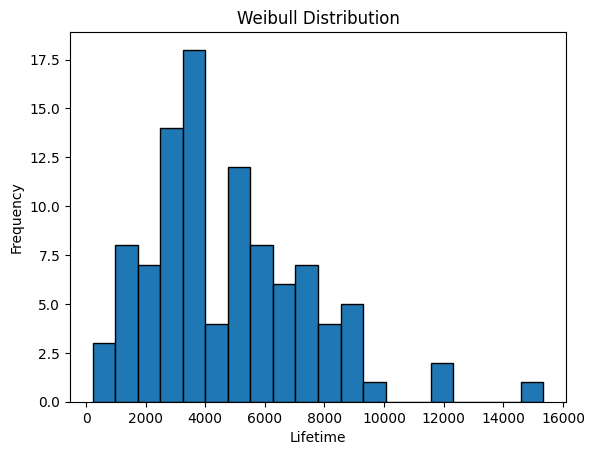

In [18]:
plt.hist(lifetimes, bins=20, edgecolor='black')

plt.xlabel('Lifetime')
plt.ylabel('Frequency')
plt.title('Weibull Distribution')

plt.show()

### Perbandingan Poisson, Exponential, dan Weibull

| Distribution | Yang Dimodelkan | Kondisi |
|---|---|---|
| Poisson | Jumlah event | Event rate konstan |
| Exponential | Waktu/jarak antar event | Event rate konstan |
| Weibull | Time-to-failure / event dengan rate yang dapat berubah | Event rate dapat berubah |

Cara mengingat:

Poisson
→ "Berapa banyak event?"

Exponential
→ "Berapa lama antara event?"

Weibull
→ "Bagaimana jika event rate berubah seiring waktu?"

### Key Ideas — Poisson and Related Distributions

1. Untuk event yang terjadi pada rate konstan, jumlah event per unit waktu atau
   ruang dapat dimodelkan dengan Poisson distribution.

2. Waktu atau jarak antara satu event dengan event berikutnya dapat dimodelkan
   menggunakan exponential distribution.

3. Jika event rate berubah seiring waktu, misalnya probabilitas kegagalan perangkat
   meningkat, kondisi tersebut dapat dimodelkan menggunakan Weibull distribution.

# Summary — Chapter 2: Data and Sampling Distributions

Chapter 2 membahas bagaimana data sampel digunakan untuk memahami populasi serta bagaimana distribusi sampling membantu menjelaskan ketidakpastian dalam estimasi statistik.

## 1. Random Sampling and Sample Bias

Random sampling digunakan untuk memperoleh sampel yang dapat merepresentasikan populasi. Pemilihan sampel yang tidak tepat dapat menghasilkan bias, yaitu kondisi ketika sampel tidak merepresentasikan populasi secara akurat.

Self-selection juga dapat menyebabkan bias karena individu memilih sendiri apakah akan berpartisipasi dalam suatu survei atau penelitian. Random selection membantu mengurangi kemungkinan terjadinya bias dalam proses pemilihan sampel.

Ukuran sampel juga penting, tetapi memperbesar ukuran sampel tidak selalu memperbaiki kualitas data apabila metode pengambilan sampelnya tetap bias.

## 2. Sample Mean Versus Population Mean

Population mean merupakan rata-rata seluruh populasi, sedangkan sample mean merupakan rata-rata dari sebagian data yang diambil sebagai sampel.

Sample mean digunakan sebagai estimator untuk memperkirakan population mean. Nilai sample mean dapat berbeda-beda antara satu sampel dengan sampel lainnya.

## 3. Sampling Distribution of a Statistic

Sampling distribution adalah distribusi nilai suatu statistik yang diperoleh dari banyak sampel yang diambil dari populasi yang sama.

Konsep ini penting karena membantu memahami bagaimana suatu statistik, seperti sample mean, dapat berubah dari satu sampel ke sampel lainnya.

## 4. Central Limit Theorem

Central Limit Theorem (CLT) menjelaskan bahwa distribusi sample mean akan semakin mendekati distribusi normal ketika ukuran sampel semakin besar, meskipun distribusi populasi asal tidak berbentuk normal.

CLT menjadi dasar penting dalam inferensi statistik dan membantu menjelaskan mengapa distribusi normal banyak digunakan dalam analisis statistik.

## 5. Standard Error

Standard error mengukur seberapa besar variasi suatu statistik sampel dari satu sampel ke sampel lainnya.

Untuk sample mean, standard error berkaitan dengan standar deviasi populasi dan ukuran sampel. Semakin besar ukuran sampel, standard error umumnya semakin kecil.

## 6. The Bootstrap

Bootstrap merupakan metode resampling yang digunakan untuk memperkirakan distribusi sampling suatu statistik.

Dalam bootstrap, sampel baru dibuat dengan mengambil pengamatan dari sampel asli secara sampling dengan replacement. Proses ini dilakukan berulang kali untuk memperoleh distribusi statistik yang kemudian dapat digunakan untuk memperkirakan ketidakpastian.

## 7. Confidence Intervals

Confidence interval memberikan rentang nilai yang digunakan untuk memperkirakan parameter populasi berdasarkan data sampel.

Bootstrap dapat digunakan untuk membentuk confidence interval dengan mengambil percentile tertentu dari distribusi bootstrap.

## 8. Probability Distributions

Chapter 2 juga membahas beberapa probability distributions yang digunakan untuk memodelkan pola data dan proses acak.

### Normal Distribution
Distribusi normal berbentuk seperti lonceng dan ditentukan oleh mean serta standard deviation. Standard normal distribution memiliki mean 0 dan standard deviation 1.

### Student's t-Distribution
Student's t-distribution memiliki bentuk yang mirip dengan distribusi normal tetapi memiliki ekor yang lebih berat. Distribusi ini digunakan terutama ketika ukuran sampel relatif kecil dan standard deviation populasi tidak diketahui.

### Binomial Distribution
Distribusi binomial digunakan untuk memodelkan jumlah keberhasilan dalam sejumlah percobaan yang memiliki dua kemungkinan hasil. Distribusi ini ditentukan oleh jumlah percobaan (n) dan probabilitas keberhasilan (p).

### Chi-Square Distribution
Chi-square distribution hanya memiliki nilai non-negatif dan bentuknya dipengaruhi oleh degrees of freedom. Distribusi ini digunakan dalam berbagai analisis statistik, termasuk analisis varians dan data kategorikal.

### F-Distribution
F-distribution digunakan untuk membandingkan variasi dan menjadi dasar dalam beberapa metode statistik, termasuk ANOVA dan analisis regresi.

### Poisson Distribution
Distribusi Poisson digunakan untuk memodelkan jumlah kejadian dalam interval waktu atau ruang tertentu ketika kejadian tersebut memiliki tingkat kejadian yang konstan.

### Exponential Distribution
Distribusi exponential digunakan untuk memodelkan waktu atau jarak antara kejadian-kejadian yang mengikuti proses dengan tingkat kejadian konstan.

### Weibull Distribution
Distribusi Weibull dapat digunakan ketika tingkat kejadian atau kegagalan berubah seiring waktu. Bentuk distribusinya memungkinkan pemodelan tingkat kegagalan yang meningkat maupun menurun.

## Key Ideas

Beberapa konsep utama yang dipelajari dalam Chapter 2 adalah:

- Random sampling membantu memperoleh sampel yang representatif.
- Bias dapat terjadi ketika proses pemilihan sampel menghasilkan sampel yang tidak representatif.
- Sample mean digunakan untuk memperkirakan population mean.
- Sampling distribution menunjukkan variasi suatu statistik dari banyak sampel.
- Central Limit Theorem menjelaskan kecenderungan distribusi sample mean mendekati distribusi normal ketika ukuran sampel semakin besar.
- Standard error menggambarkan variasi statistik sampel.
- Bootstrap menggunakan resampling dengan replacement untuk memperkirakan distribusi sampling.
- Confidence interval memberikan rentang estimasi untuk parameter populasi.
- Normal, t, binomial, chi-square, F, Poisson, exponential, dan Weibull merupakan beberapa distribusi probabilitas yang dibahas dalam chapter ini.